# Air-raid alerts in Ukraine — time-series analysis

**Thesis (punchline up front):** the daily alert count *looks* like it might carry a weekly rhythm, but it does not — the series is almost entirely **trend**, and weekly seasonality adds **nothing** to forecasts. That negative result is the finding, reached by letting the data decide.

Reader path: **data → EDA → STL decomposition → walk-forward forecasting → why a 'zero-seasonality' result is the point.**

> This notebook is a **thin narrative wrapper**. All logic lives in `src/` (the source of truth); here we only *call* those functions and add commentary. Full written findings: [`reports/INSIGHTS.md`](../reports/INSIGHTS.md).

In [1]:
# Make the project root the working dir so `src` imports and relative paths resolve,
# whether this notebook is launched from notebooks/ or the repo root.
import os, sys
from pathlib import Path

root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from IPython.display import Image, display
from src.data_loader import load_raw_alerts, quality_report
from src.build_dataset import build_daily
from src.plots import (fig_daily_count, fig_regions_per_day,
                       fig_duration_boxplot, fig_recent_zoom)
import src.decomposition as decomposition
import src.forecasting as forecasting

print('Project root set; src is importable.')

Project root set; src is importable.


## 1. Data

Volunteer dataset (oblast level, UTC → Kyiv). We load the raw interval data and print an empirical quality report — no assumptions baked in.

In [2]:
raw = load_raw_alerts('volunteer')
quality_report(raw)

rows: 101,266
date range (Kyiv): 2022-02-25 18:36:22+02:00  ->  2026-06-20 03:45:41+03:00
unique regions: 25
  sample: ['Cherkaska oblast', 'Chernihivska oblast', 'Chernivetska oblast', 'Dnipropetrovska oblast', 'Donetska oblast', 'Ivano-Frankivska oblast', 'Kharkivska oblast', 'Khersonska oblast']
naive=True share: 4.9%  (4,998 rows)
missing finished_at: 0
non-positive duration (end <= start): 5

duration_min by naive flag:
         count       mean    50%      max
naive                                    
False  96268.0  51.403927  32.65  10695.9
True    4998.0  30.000000  30.00     30.0


**Takeaways.** ~101k alerts over 1 577 continuous days — **no missing days, no zero-alert days** (min 6/day). `naive=True` (4.94%) is a fixed **30-min placeholder** (all exactly 30.0 min, std 0): kept for the count target, excluded from duration analysis. 25 regions, stable over time; Luhansk (occupied) is effectively absent (3 records).

In [3]:
# Modeling target A: national daily region-alert count (partial last day dropped).
daily = build_daily('volunteer')
display(daily.describe().round(1))
daily.tail()

,alert_count,regions_under_alert
count,1576.0,1576.0
mean,64.2,17.5
std,26.6,5.4
min,6.0,3.0
25%,46.0,13.8
50%,62.0,17.0
75%,79.0,24.0
max,192.0,24.0


,alert_count,regions_under_alert
date,,
2026-06-15,75,20
2026-06-16,75,14
2026-06-17,71,12
2026-06-18,115,21
2026-06-19,105,16


## 2. EDA — the shape of the series

**Daily alert count (A).** The 30-day mean is far from flat: a trough ~26 (Dec 2022) rising ~4.4× to ~110 (2026). A strongly trending, non-stationary series.

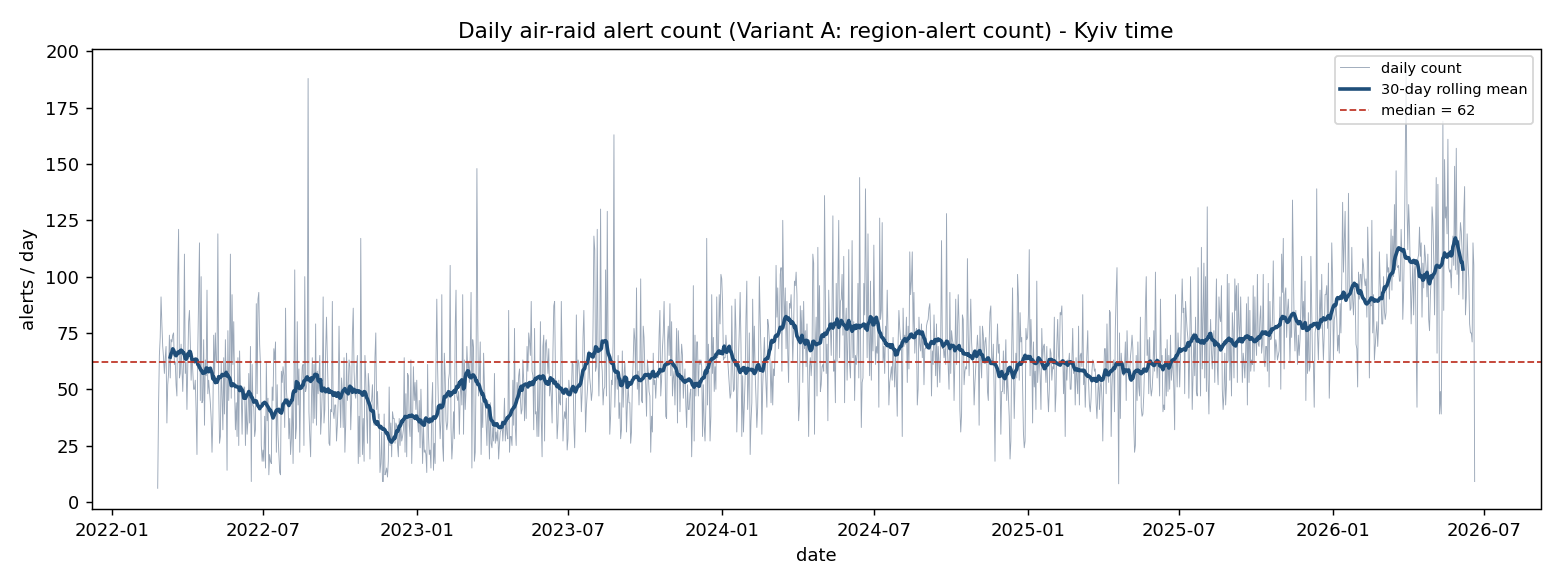

In [4]:
p, _ = fig_daily_count(raw)
display(Image(str(p)))

**Recent zoom.** The level is flat (~60) through mid-2025, then steps up from ~July 2025 — the regime change we use as the forecasting train start (2025-07-01).

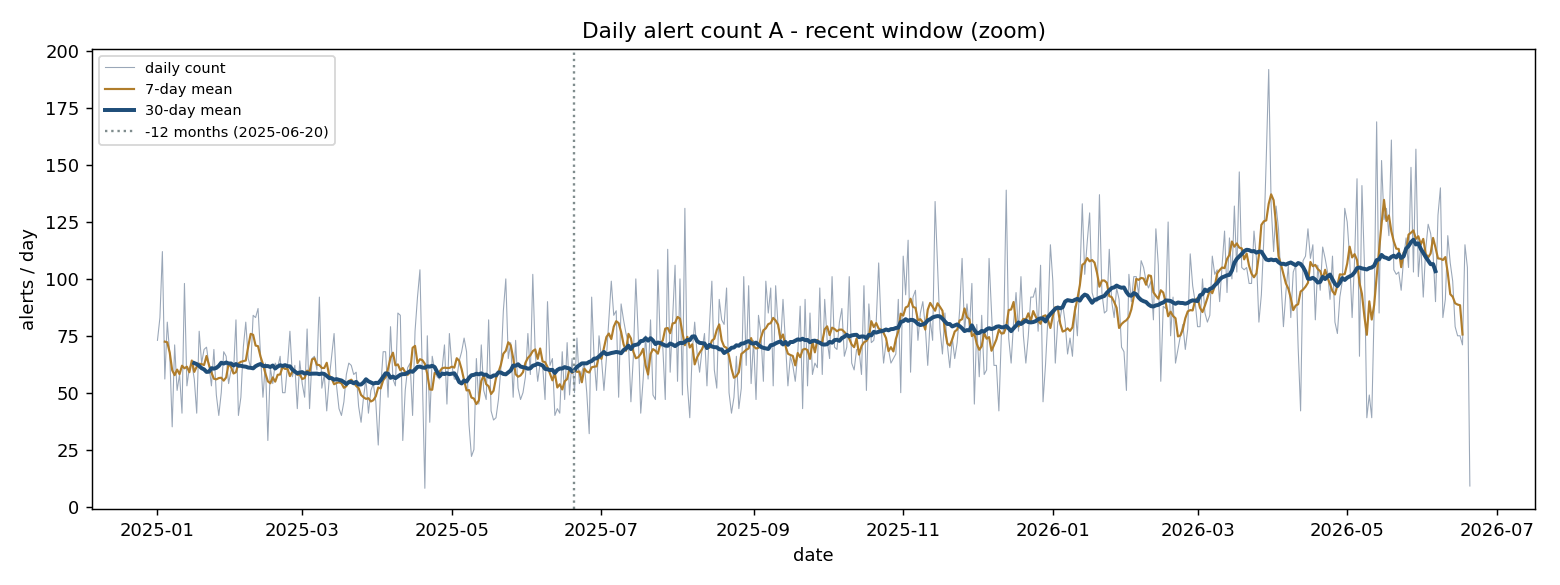

In [5]:
p, _ = fig_recent_zoom(raw)
display(Image(str(p)))

**Depth, not breadth.** Distinct oblasts under alert per day stay range-bound (~13–21) while the count rose 4.4× → the escalation is *more alerts per region*, not wider geography. This is why the count target is meaningful and not geographic inflation.

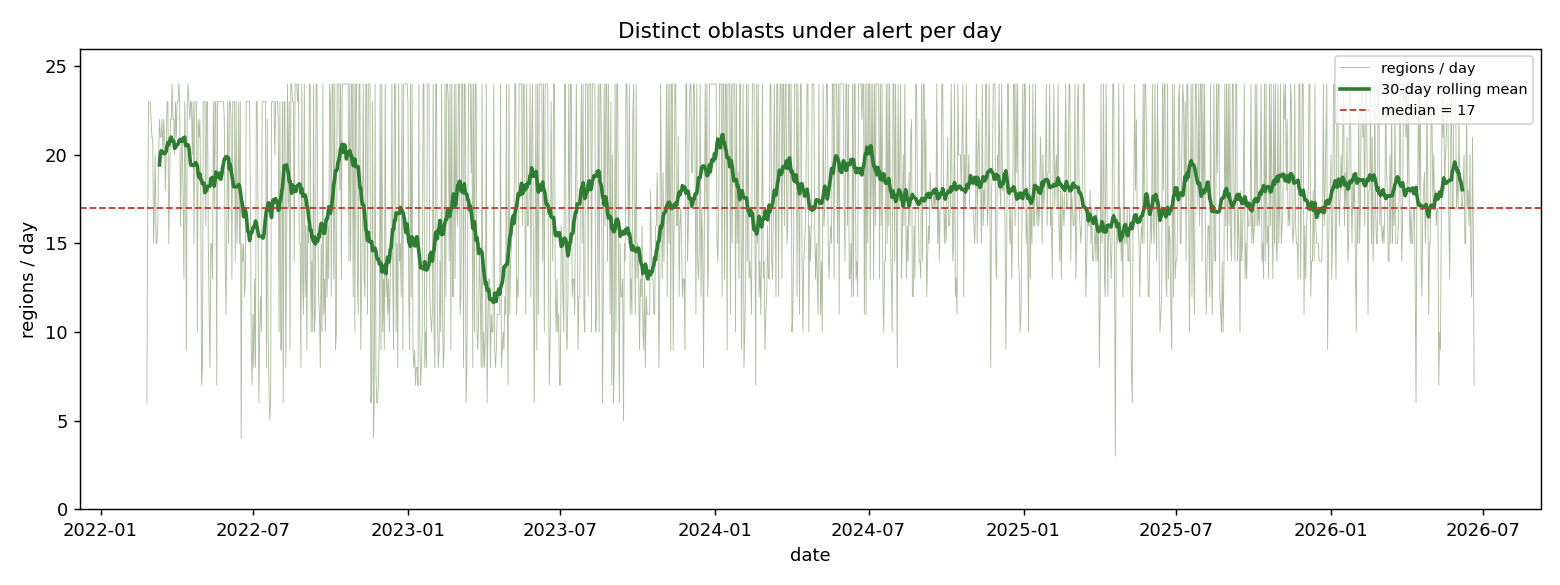

In [6]:
p, _ = fig_regions_per_day(raw)
display(Image(str(p)))

**The `naive` flag, visually.** `naive=True` collapses to a single line at exactly 30 min — confirming the placeholder. Hence it is excluded from any duration analysis (but kept for the count target).

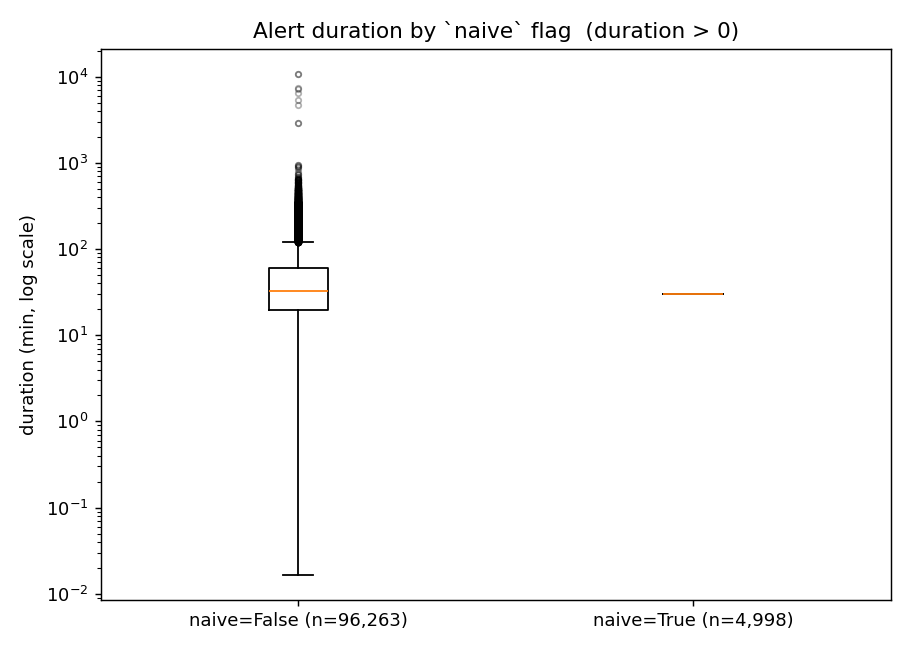

In [7]:
p = fig_duration_boxplot(raw)
display(Image(str(p)))

## 3. STL decomposition

Decompose the daily series (weekly period) and quantify how strong trend vs. seasonality actually is. `decomposition.main()` prints the raw numbers and (re)saves the figure.

In [8]:
decomposition.main()

saved reports/figures/05_stl_decomposition.png

RAW decomposition numbers:
  trend: start=67.1  end=83.4
  weekly seasonal amplitude (max-min DoW effect): 9.7
  residual std: 17.60
  strength of trend     F_T = 0.517
  strength of seasonal  F_S = 0.176

  mean weekly seasonal effect by day-of-week (alerts vs. trend):
Mon    0.29
Tue   -0.68
Wed    0.68
Thu    4.77
Fri    0.53
Sat   -0.65
Sun   -4.91

  weekly seasonal effect by YEAR x day-of-week (stability check):
       Mon   Tue   Wed    Thu   Fri   Sat   Sun
date                                           
2022  1.75  0.91 -0.49  10.56 -6.21 -4.41 -2.18
2023 -0.84  0.12  1.05   7.24  1.23 -2.80 -5.75
2024  2.17 -0.19  2.66   0.13  1.85 -0.61 -6.19
2025 -0.19 -4.70  1.25   2.11  1.62  3.95 -4.05
2026 -3.03  2.27 -3.49   4.66  6.19  1.03 -7.19


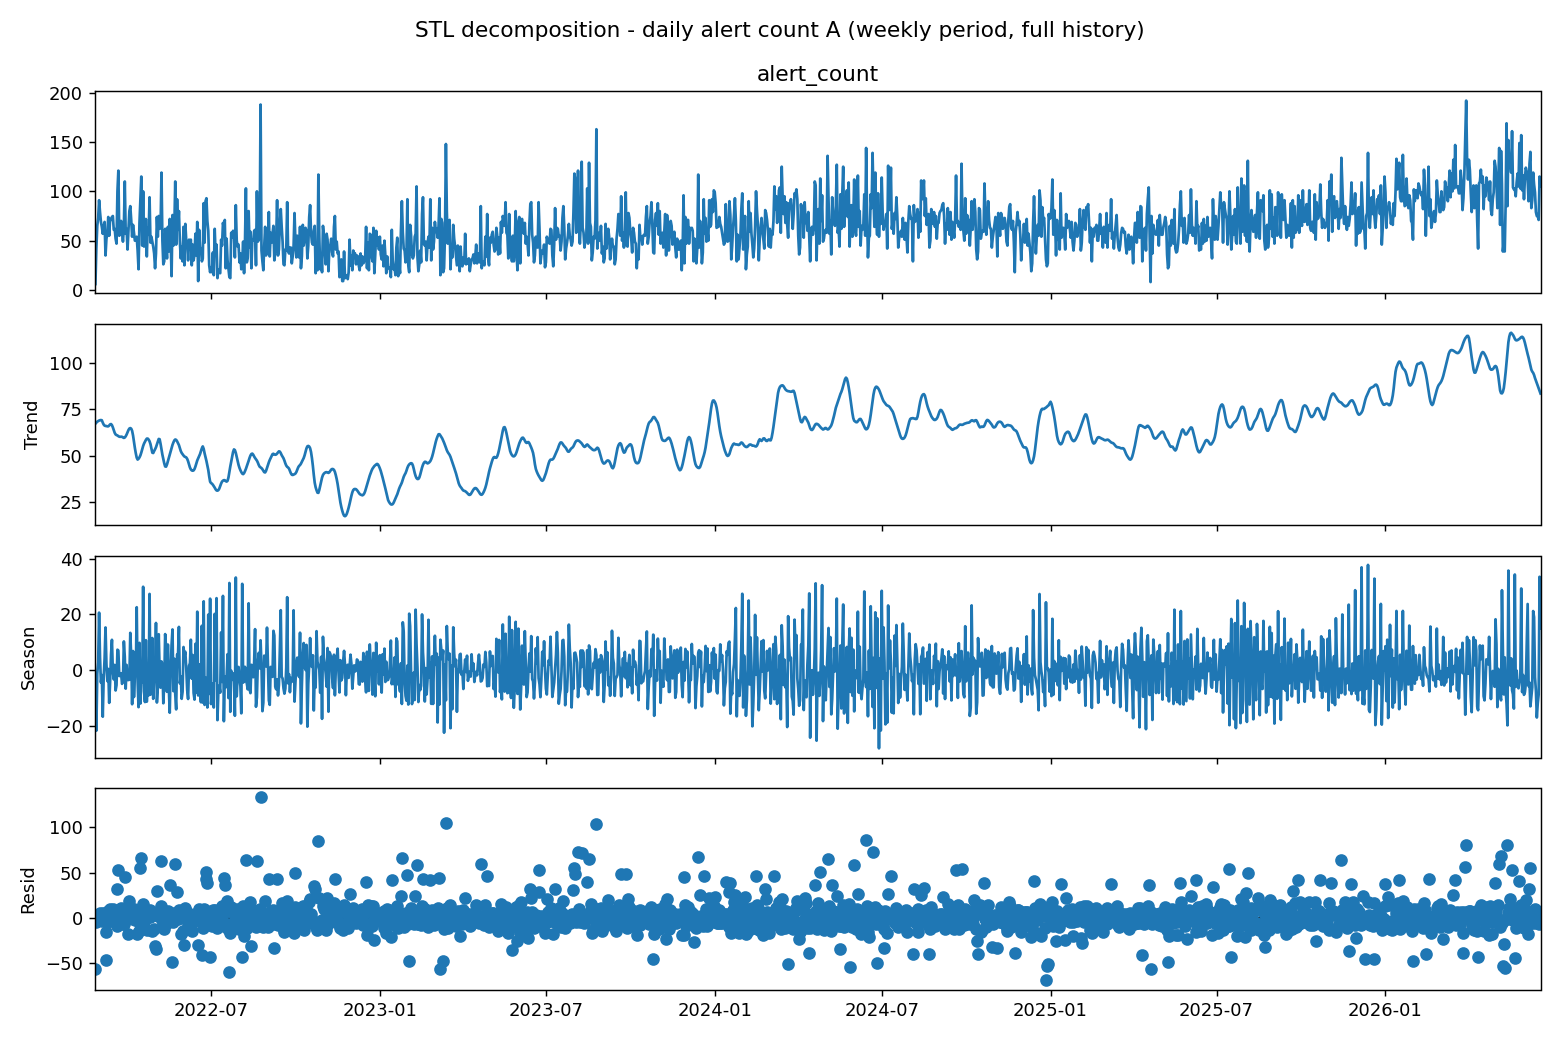

In [9]:
display(Image('reports/figures/05_stl_decomposition.png'))

**The decisive numbers.** Strength of trend `F_T = 0.52` vs. weekly seasonality `F_S = 0.18` — seasonality is weak, and residual noise (std 17.6) is *larger* than the whole weekly amplitude (9.7). The year × day-of-week table shows the **only stable weekly signal is that Sunday is the quietest day**; the 'Thursday peak' is a 2022–23 artifact that vanishes by 2024. So we report 'weekends are quieter', not 'Thursday is busiest'.

## 4. Walk-forward forecasting

12 consecutive weekly folds (h=7), expanding window from 2025-07-01. **Two baselines** (seasonal-naive, naive-with-drift) plus a **diagnostic**: trend-only Holt vs. full Holt-Winters. Metrics are reported **per fold**, not as a single aggregate.

In [10]:
forecasting.main()

MAE per fold (method x fold):
                  fold  n_train  seasonal_naive  naive_drift  holt_no_seas  hw_add  hw_mul
2026-03-28..2026-04-03      270           36.43        43.73         39.48   39.47   39.69
2026-04-04..2026-04-10      277           41.43        27.11         22.90   23.96   23.70
2026-04-11..2026-04-17      284           19.71        18.69         17.95   19.17   20.58
2026-04-18..2026-04-24      291           19.43        15.69          9.20   11.89   12.30
2026-04-25..2026-05-01      298           23.71        17.92         17.33   16.26   16.01
2026-05-02..2026-05-08      305           21.14        26.94         20.85   18.03   17.53
2026-05-09..2026-05-15      312           62.00        49.08         48.35   49.10   49.20
2026-05-16..2026-05-22      319           64.86        34.50         17.75   19.10   19.72
2026-05-23..2026-05-29      326           30.00        18.48         17.46   19.66   20.23
2026-05-30..2026-06-05      333           19.29        47.11

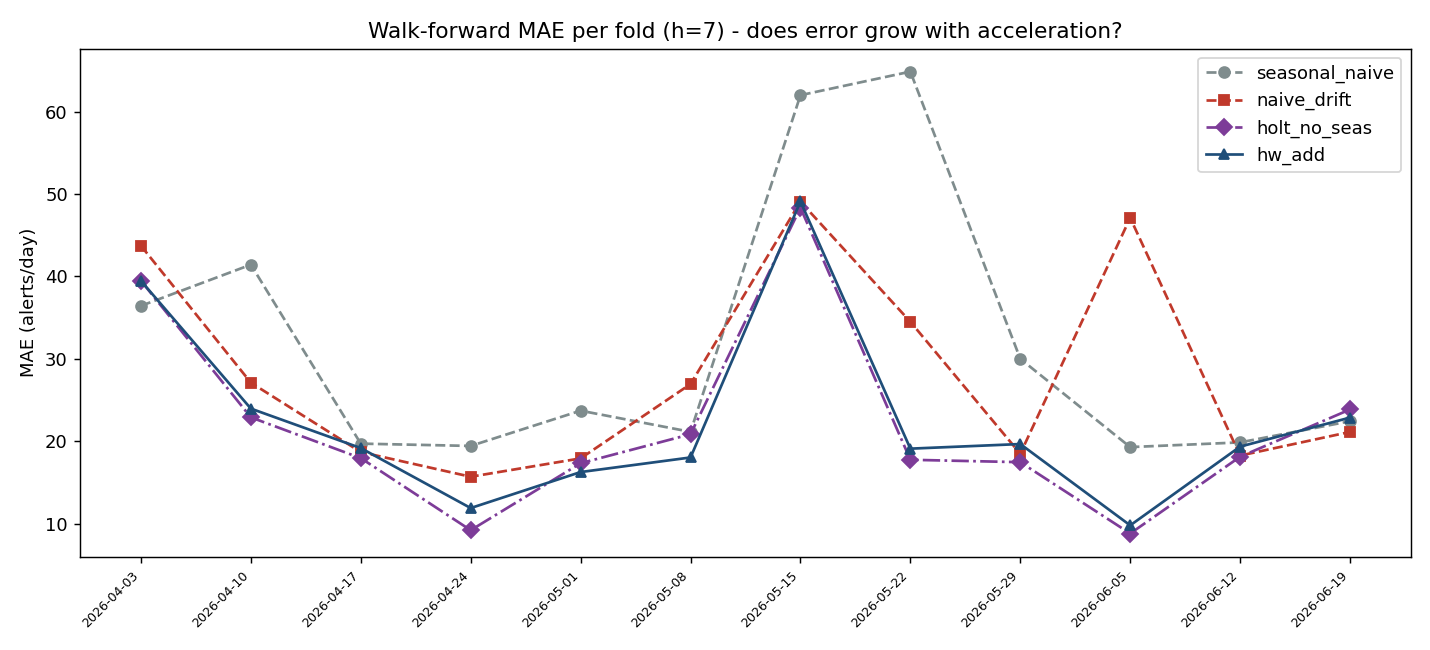

In [11]:
display(Image('reports/figures/06_walkforward_mae.png'))

**Why the zero.** `holt_no_seas` (trend only) ≈ `hw_add` (trend + weekly seasonality) on every fold — adding seasonality changes nothing. Both clearly beat naive-with-drift (28.2 MAE) and seasonal-naive (31.7); the edge over drift is robust **trend/level smoothing**, not day-of-week structure. Error is **event-driven** (note the 2026-05-09 spike hitting all methods), not steadily growing with the acceleration.

## 5. Why a 'no-seasonality' result is the point

The honest chain: STL said weekly seasonality is weak (`F_S = 0.18`) → the walk-forward diagnostic confirmed it operationally (a **trend-only** model is the best performer; the seasonal model adds nothing) → so the predictability in Ukraine's air-raid alerts is almost entirely **trend / momentum**, with a small, only-partly-stable weekly effect (Sunday quieter).

This was **pre-registered**: we accepted, before seeing the metrics, that the seasonal model might not win — and did not tune it to. A clean negative result, driven by the data. Full detail: [`reports/INSIGHTS.md`](../reports/INSIGHTS.md).